# Pipeline de Dados — Google Trends

### Objetivo:
Extrair o volume de buscas por termos relacionados a sistemas de aquecimento de água no Brasil, por estado e ao longo do tempo, para identificar o interesse real do consumidor e sua correlação com o perfil climático regional.
### Termos monitorados:
   - "aquecimento solar"
   - "aquecimento de piscina"
   - "aquecedor solar"
   - "chuveiro elétrico"
   - "bomba de calor"
### Fonte:
Google Trends (via biblioteca pytrends)
- Período: últimos 5 anos | Granularidade: semanal
- Cobertura geográfica: Brasil — por Unidade da Federação



In [1]:
# ------------------------------------------------------------
# 1. MONTAGEM DO GOOGLE DRIVE
# ------------------------------------------------------------
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# ------------------------------------------------------------
# 2. IMPORTAÇÃO DAS BIBLIOTECAS
# ------------------------------------------------------------
!pip install pytrends -q

import time
import pandas as pd
import matplotlib.pyplot as plt
from pytrends.request import TrendReq

In [3]:
# ------------------------------------------------------------
# 3. CONFIGURAÇÃO
# ------------------------------------------------------------

# Termos de busca — máximo 5 por requisição no Google Trends
TERMOS = [
    "aquecimento solar",
    "aquecimento de piscina",
    "aquecedor solar",
    "chuveiro elétrico",
    "bomba de calor"
]

# Mapeamento dos códigos de estado do Google Trends para siglas IBGE
MAPA_ESTADO = {
    "Acre": "AC", "Alagoas": "AL", "Amapá": "AP", "Amazonas": "AM",
    "Bahia": "BA", "Ceará": "CE", "Distrito Federal": "DF",
    "Espírito Santo": "ES", "Goiás": "GO", "Maranhão": "MA",
    "Mato Grosso": "MT", "Mato Grosso do Sul": "MS", "Minas Gerais": "MG",
    "Pará": "PA", "Paraíba": "PB", "Paraná": "PR", "Pernambuco": "PE",
    "Piauí": "PI", "Rio de Janeiro": "RJ", "Rio Grande do Norte": "RN",
    "Rio Grande do Sul": "RS", "Rondônia": "RO", "Roraima": "RR",
    "Santa Catarina": "SC", "São Paulo": "SP", "Sergipe": "SE",
    "Tocantins": "TO"
}

# Inicializar cliente do Google Trends
# hl: idioma | tz: fuso horário (180 = UTC-3, horário de Brasília)
pytrends = TrendReq(hl="pt-BR", tz=180)

In [4]:
# ------------------------------------------------------------
# 4. COLETA DOS DADOS — SÉRIE TEMPORAL NACIONAL
# Volume de buscas semanal por termo nos últimos 5 anos
# ------------------------------------------------------------

print("Coletando série temporal nacional...")

pytrends.build_payload(
    kw_list=TERMOS,
    timeframe="today 5-y",
    geo="BR"
)

df_tempo_bruto = pytrends.interest_over_time()
print(f"Shape bruto série temporal: {df_tempo_bruto.shape}")
print(df_tempo_bruto.head())

# Aguardar para evitar bloqueio por rate limit
time.sleep(5)

Coletando série temporal nacional...


/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


Shape bruto série temporal: (262, 5)
            aquecedor solar  coletor solar  bomba de calor  chuveiro elétrico  \
date                                                                            
2021-06-06               33              4               4                 47   
2021-06-13               45              5               3                 59   
2021-06-20               43              4               3                 54   
2021-06-27               67              4               4                 62   
2021-07-04               58              6               3                 53   

            isPartial  
date                   
2021-06-06      False  
2021-06-13      False  
2021-06-20      False  
2021-06-27      False  
2021-07-04      False  


In [5]:
# ------------------------------------------------------------
# 5. COLETA DOS DADOS — DISTRIBUIÇÃO POR ESTADO
# Interesse médio por termo em cada UF nos últimos 5 anos
# ------------------------------------------------------------

print("\nColetando distribuição por estado...")

pytrends.build_payload(
    kw_list=TERMOS,
    timeframe="today 5-y",
    geo="BR"
)

df_estado_bruto = pytrends.interest_by_region(
    resolution="REGION",
    inc_low_vol=True,
    inc_geo_code=True
)

print(f"Shape bruto por estado: {df_estado_bruto.shape}")
print(df_estado_bruto.head())


Coletando distribuição por estado...
Shape bruto por estado: (27, 5)
         geoCode  aquecedor solar  coletor solar  bomba de calor  \
geoName                                                            
Acre       BR-AC                9              0               0   
Alagoas    BR-AL                9              1               3   
Amapá      BR-AP               10              0               0   
Amazonas   BR-AM                8              4               6   
Bahia      BR-BA               12              2               4   

          chuveiro elétrico  
geoName                      
Acre                     91  
Alagoas                  87  
Amapá                    90  
Amazonas                 82  
Bahia                    82  


In [6]:
# ------------------------------------------------------------
# 6. INSPEÇÃO INICIAL
# ------------------------------------------------------------

print("\n=== SÉRIE TEMPORAL ===")
print(df_tempo_bruto.info())
print(df_tempo_bruto.describe())

print("\n=== POR ESTADO ===")
print(df_estado_bruto.info())
print(df_estado_bruto.describe())


=== SÉRIE TEMPORAL ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 262 entries, 2021-06-06 to 2026-06-07
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   aquecedor solar    262 non-null    int64
 1   coletor solar      262 non-null    int64
 2   bomba de calor     262 non-null    int64
 3   chuveiro elétrico  262 non-null    int64
 4   isPartial          262 non-null    bool 
dtypes: bool(1), int64(4)
memory usage: 10.5 KB
None
       aquecedor solar  coletor solar  bomba de calor  chuveiro elétrico
count       262.000000     262.000000      262.000000         262.000000
mean         24.278626       2.885496        5.419847          41.473282
std           9.783217       1.310969        2.598125          12.691342
min          12.000000       0.000000        0.000000          19.000000
25%          18.000000       2.000000        4.000000          32.000000
50%          22.000000       3.000000   

In [7]:
# ------------------------------------------------------------
# 7. LIMPEZA E TRATAMENTO — SÉRIE TEMPORAL
# ------------------------------------------------------------

df_tempo = df_tempo_bruto.copy()

# Remover coluna isPartial gerada pelo pytrends
if "isPartial" in df_tempo.columns:
    df_tempo = df_tempo.drop(columns=["isPartial"])

# Resetar índice (data vira coluna)
df_tempo = df_tempo.reset_index()
df_tempo = df_tempo.rename(columns={"date": "data"})

# Converter para formato longo
df_tempo = df_tempo.melt(
    id_vars="data",
    var_name="termo",
    value_name="indice_busca"
)

# Extrair ano e mês
df_tempo["ano"] = df_tempo["data"].dt.year
df_tempo["mes"] = df_tempo["data"].dt.month

print(f"\nShape série temporal tratada: {df_tempo.shape}")
print(df_tempo.head(10))


Shape série temporal tratada: (1048, 5)
        data            termo  indice_busca   ano  mes
0 2021-06-06  aquecedor solar            33  2021    6
1 2021-06-13  aquecedor solar            45  2021    6
2 2021-06-20  aquecedor solar            43  2021    6
3 2021-06-27  aquecedor solar            67  2021    6
4 2021-07-04  aquecedor solar            58  2021    7
5 2021-07-11  aquecedor solar            47  2021    7
6 2021-07-18  aquecedor solar            91  2021    7
7 2021-07-25  aquecedor solar            70  2021    7
8 2021-08-01  aquecedor solar            59  2021    8
9 2021-08-08  aquecedor solar            45  2021    8


In [8]:
# ------------------------------------------------------------
# 8. LIMPEZA E TRATAMENTO — POR ESTADO
# ------------------------------------------------------------

df_estado = df_estado_bruto.copy()

# Resetar índice (nome do estado vira coluna)
df_estado = df_estado.reset_index()
df_estado = df_estado.rename(columns={"geoName": "estado"})

# Mapear nome do estado para sigla IBGE
df_estado["uf"] = df_estado["estado"].map(MAPA_ESTADO)

# Remover coluna geoCode se existir
if "geoCode" in df_estado.columns:
    df_estado = df_estado.drop(columns=["geoCode"])

# Converter para formato longo
df_estado = df_estado.melt(
    id_vars=["estado", "uf"],
    var_name="termo",
    value_name="indice_busca"
)

# Verificar estados não mapeados
nulos = df_estado["uf"].isna().sum()
print(f"\nEstados não mapeados: {nulos}")
if nulos > 0:
    print(df_estado[df_estado["uf"].isna()]["estado"].unique())

print(f"\nShape por estado tratado: {df_estado.shape}")
print(df_estado.head(10))



Estados não mapeados: 0

Shape por estado tratado: (108, 4)
             estado  uf            termo  indice_busca
0              Acre  AC  aquecedor solar             9
1           Alagoas  AL  aquecedor solar             9
2             Amapá  AP  aquecedor solar            10
3          Amazonas  AM  aquecedor solar             8
4             Bahia  BA  aquecedor solar            12
5             Ceará  CE  aquecedor solar             9
6  Distrito Federal  DF  aquecedor solar            34
7    Espírito Santo  ES  aquecedor solar            24
8             Goiás  GO  aquecedor solar            37
9          Maranhão  MA  aquecedor solar            10


In [9]:
# ------------------------------------------------------------
# 9. VERIFICAÇÃO PÓS-LIMPEZA
# ------------------------------------------------------------

print("\n=== SÉRIE TEMPORAL — verificação ===")
print(df_tempo.groupby("termo")["indice_busca"].describe())

print("\n=== POR ESTADO — verificação ===")
print(df_estado.groupby("termo")["indice_busca"].describe())



=== SÉRIE TEMPORAL — verificação ===
                   count       mean        std   min   25%   50%   75%    max
termo                                                                        
aquecedor solar    262.0  24.278626   9.783217  12.0  18.0  22.0  28.0   91.0
bomba de calor     262.0   5.419847   2.598125   0.0   4.0   5.0   7.0   14.0
chuveiro elétrico  262.0  41.473282  12.691342  19.0  32.0  39.0  48.0  100.0
coletor solar      262.0   2.885496   1.310969   0.0   2.0   3.0   4.0    9.0

=== POR ESTADO — verificação ===
                   count       mean        std   min   25%   50%   75%   max
termo                                                                       
aquecedor solar     27.0  19.555556  14.658506   6.0   9.0  12.0  27.5  62.0
bomba de calor      27.0   5.148148   2.983335   0.0   3.5   5.0   7.0  12.0
chuveiro elétrico   27.0  71.925926  17.709028  31.0  56.5  82.0  86.0  92.0
coletor solar       27.0   3.370370   1.842827   0.0   2.0   4.0   4.5   7.

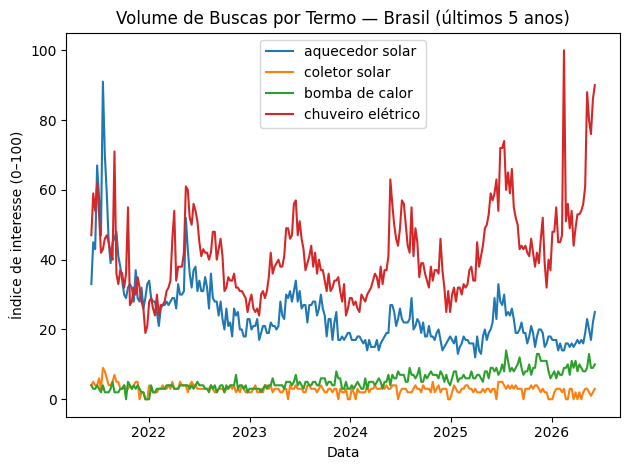

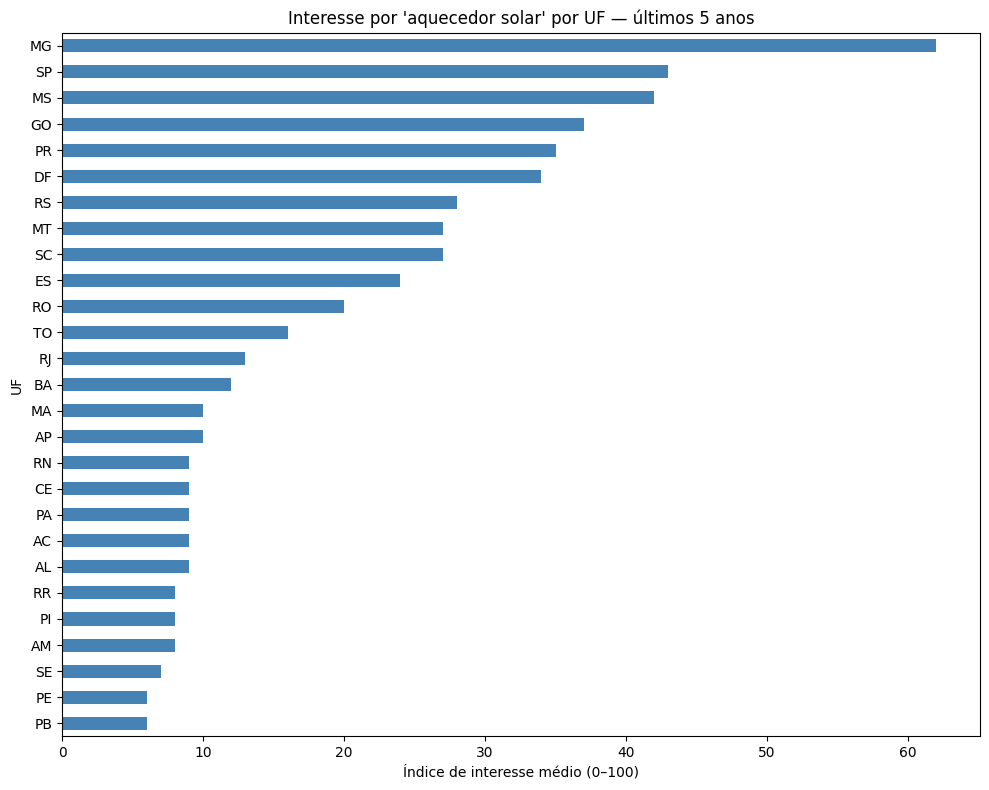

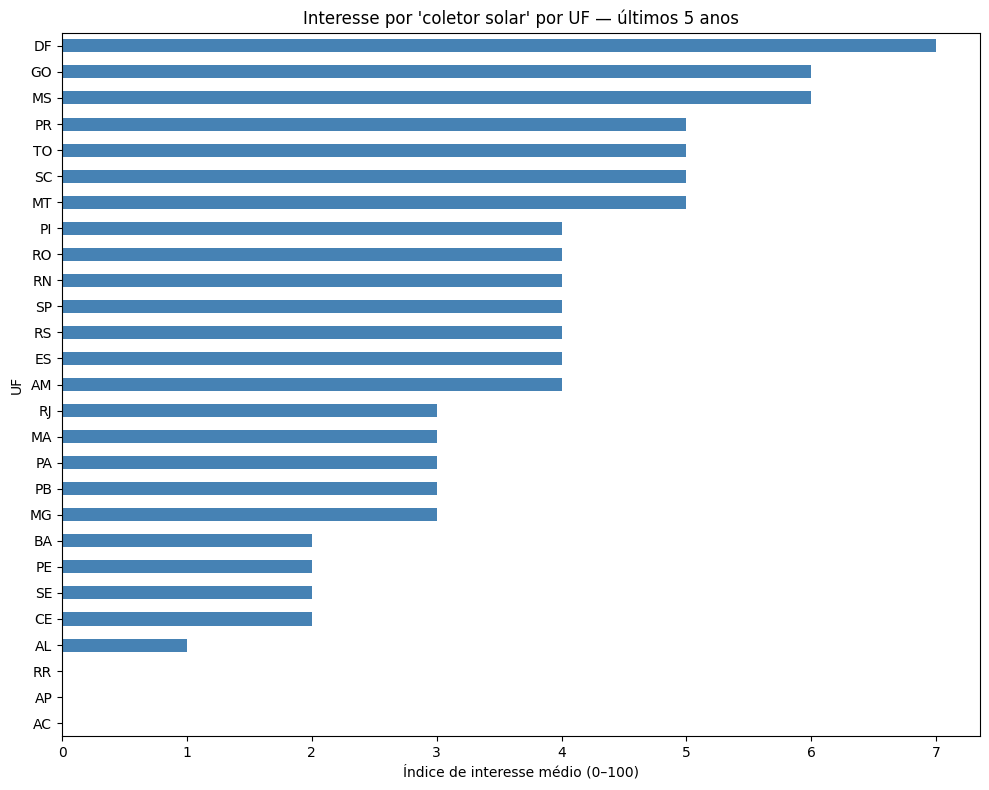

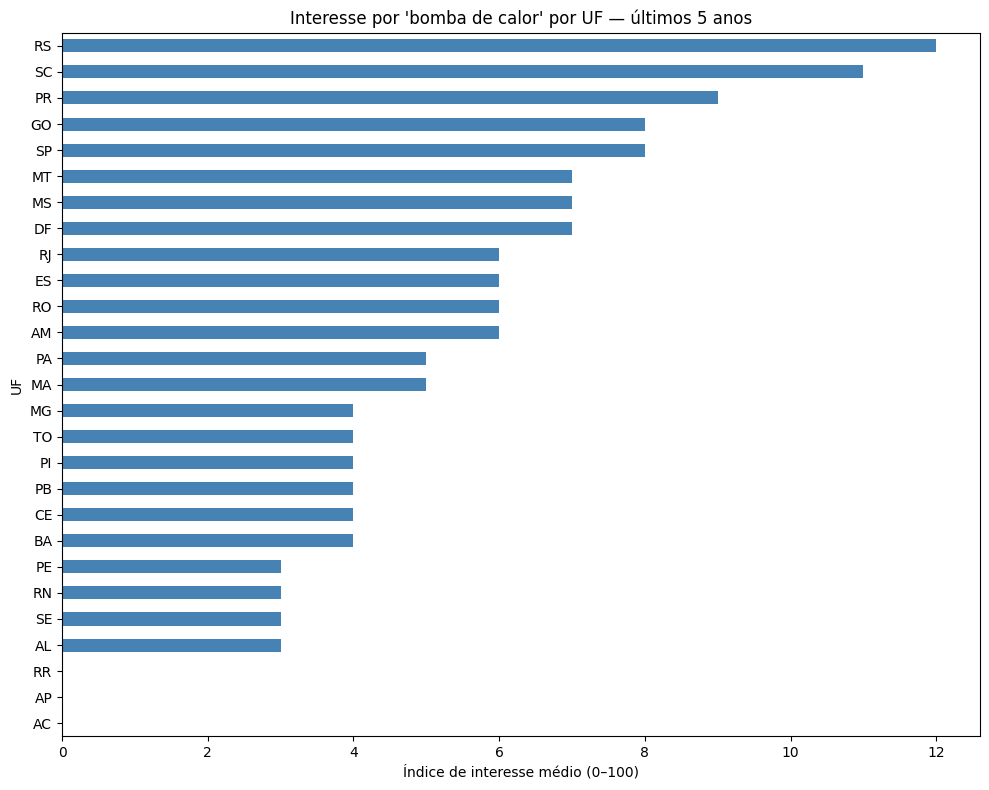

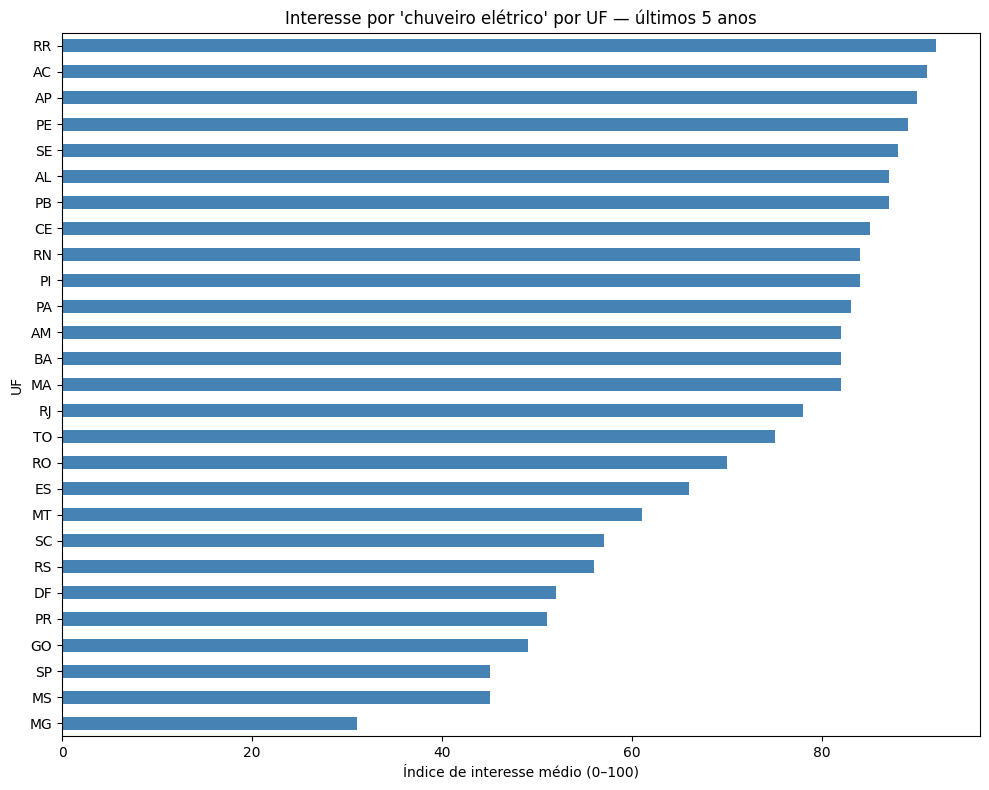

In [10]:
# ------------------------------------------------------------
# 10. VISUALIZAÇÕES INICIAIS
# Como evoluiu o interesse pelos termos ao longo do tempo?
# ------------------------------------------------------------

for termo in TERMOS:
    dados = df_tempo[df_tempo["termo"] == termo]
    plt.plot(dados["data"], dados["indice_busca"], label=termo)

plt.title("Volume de Buscas por Termo — Brasil (últimos 5 anos)")
plt.xlabel("Data")
plt.ylabel("Índice de interesse (0–100)")
plt.legend()
plt.tight_layout()
plt.show()


# Qual estado tem maior interesse por cada termo?
for termo in TERMOS:
    dados = (
        df_estado[df_estado["termo"] == termo]
        .dropna(subset=["uf"])
        .sort_values("indice_busca", ascending=True)
    )

    dados.plot(
        kind="barh",
        x="uf",
        y="indice_busca",
        figsize=(10, 8),
        legend=False,
        color="steelblue"
    )
    plt.title(f"Interesse por '{termo}' por UF — últimos 5 anos")
    plt.xlabel("Índice de interesse médio (0–100)")
    plt.ylabel("UF")
    plt.tight_layout()
    plt.show()


In [11]:
# ------------------------------------------------------------
# 11. EXPORTAÇÃO
# ------------------------------------------------------------

df_tempo.to_csv(
    "/content/drive/MyDrive/dados_projeto_ciencia_dados/gtrends_serie_temporal.csv",
    index=False,
    encoding="utf-8-sig"
)

df_estado.to_csv(
    "/content/drive/MyDrive/dados_projeto_ciencia_dados/gtrends_por_estado.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Arquivos exportados com sucesso.")

Arquivos exportados com sucesso.
